# Clase 6: Taller Práctico - Random Forest y Boosting

**Objetivos del Taller:**

1.  Aplicar los algoritmos de Random Forest y Gradient Boosting a un problema de clasificación.
2.  Entender cómo extraer y visualizar la importancia de las variables para interpretar los modelos.
3.  Comparar el rendimiento y las características de ambos métodos de ensamble.
4.  Experimentar con los hiperparámetros clave de cada modelo.

Utilizaremos el dataset `Heart`, que contiene datos de pacientes para predecir la presencia de enfermedades cardíacas.

In [2]:
# --- 1. Importación de Librerías ---
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Clases de Scikit-Learn para modelos y evaluación
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Librería del libro para cargar el dataset
# from ISLP import load_data

## 2. Carga y Exploración de Datos

Cargaremos el dataset `Heart` desde la librería `ISLP`. Este dataset es ideal para un problema de clasificación binaria.

In [3]:
import pandas as pd

# URL canónica del dataset Heart usado en el libro ISLP
url = 'https://www.statlearning.com/s/Heart.csv'

# Usamos pandas para leer el archivo CSV directamente desde la web
heart_df = pd.read_csv(url)

# A menudo, al cargar así, se crea una columna de índice no deseada. La eliminamos.
if 'Unnamed: 0' in heart_df.columns:
    heart_df = heart_df.drop('Unnamed: 0', axis=1)

# Verificamos que los datos se hayan cargado correctamente
print('Datos cargados exitosamente desde la URL:')
display(heart_df.head())

print('\\nInformación del Dataset:')
heart_df.info()

Datos cargados exitosamente desde la URL:


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


\nInformación del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


In [4]:
for col_name in heart_df.select_dtypes(include=['object']).columns.tolist():
    print(f"Valores únicos en '{col_name}': {heart_df[col_name].unique()}")

Valores únicos en 'ChestPain': ['typical' 'asymptomatic' 'nonanginal' 'nontypical']
Valores únicos en 'Thal': ['fixed' 'normal' 'reversable' nan]
Valores únicos en 'AHD': ['No' 'Yes']


### 2.1. Preparación de los Datos

Para que los algoritmos de Scikit-learn funcionen correctamente, necesitamos realizar algunos pasos de preprocesamiento:

1.  **Limpieza de Nulos:** Verificar y eliminar filas con valores nulos para simplificar el análisis.
2.  **Codificación de Variables Categóricas:** Convertir columnas de texto (como `ChestPain`, `Thal`) en variables numéricas usando One-Hot Encoding.
3.  **Separación de Datos:** Dividir el dataset en un conjunto de características (`X`) y una variable objetivo (`y`).
4.  **División en Entrenamiento y Prueba:** Particionar los datos para entrenar el modelo y evaluarlo en datos no vistos.

In [5]:
# 1. Limpieza de Nulos
heart_df_clean = heart_df.dropna()

# 2. Separación de características (X) y objetivo (y)
X = heart_df_clean.drop('AHD', axis=1)
y = heart_df_clean['AHD']

# 3. Codificación One-Hot para variables categóricas
# pd.get_dummies convierte columnas categóricas en 0s y 1s
X_encoded = pd.get_dummies(X, drop_first=True)

print('Columnas después de la codificación One-Hot:')
print(X_encoded.columns)

# 4. División en conjuntos de entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTamaño del set de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del set de prueba: {X_test.shape[0]} muestras')

Columnas después de la codificación One-Hot:
Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal',
       'Thal_reversable'],
      dtype='object')

Tamaño del set de entrenamiento: 237 muestras
Tamaño del set de prueba: 60 muestras


## 3. Random Forest

Ahora, entrenaremos nuestro primer modelo de ensamble. Un `RandomForestClassifier` es una colección de árboles de decisión entrenados en subconjuntos de datos y características, cuyas predicciones se combinan para obtener un resultado final más robusto.

In [6]:
# Instanciar el clasificador de Random Forest
# n_estimators: número de árboles en el bosque.
# random_state: para reproducibilidad de los resultados.
rf_model = RandomForestClassifier(n_estimators=100, random_state=100, oob_score=True)

# Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Evaluación de Random Forest ---
Accuracy: 0.8167
Error OOB (Out-of-Bag): 0.2025
Accuracy OOB: 0.7975

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.88      0.84        32
         Yes       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



### 3.1. Importancia de Variables
Una de las grandes ventajas de Random Forest es que nos permite medir qué tan importante fue cada variable para la predicción. Lo visualizaremos para entender mejor qué factores influyen más en el diagnóstico.

In [7]:
# Extraer la importancia de las variables
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# Crear un DataFrame para facilitar la visualización
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualizar con Plotly Express
fig = px.bar(
    importance_df.head(15),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Importancia de las Variables (Random Forest)',
    labels={'Feature': 'Variable', 'Importance': 'Importancia'}
)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Mapeo de colores
color_map = {"Yes": "blue", "No": "red"}
ca_values = [0, 1, 2, 3]
titles = [f'Ca = {val}' for val in ca_values]
positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

fig = make_subplots(rows=2, cols=2, subplot_titles=titles)

for idx, ca_val in enumerate(ca_values):
    row, col = positions[idx]
    df_plot = heart_df_clean[heart_df_clean["Ca"] == ca_val]
    show_legend = (idx == 0)
    for ahd_val in ["Yes", "No"]:
        df_class = df_plot[df_plot["AHD"] == ahd_val]
        fig.add_trace(
            go.Scatter(x=df_class["Oldpeak"], y=df_class["MaxHR"], mode="markers",
                marker=dict(color=color_map[ahd_val]), name=ahd_val, showlegend=show_legend,
            ), row=row, col=col
        )
    show_legend = False

# Set axis titles for all subplots
for r in [1, 2]:
    for c in [1, 2]:
        fig.update_xaxes(title_text="Oldpeak", row=r, col=c)
        fig.update_yaxes(title_text="MaxHR", row=r, col=c)


fig.update_layout(
    height=800,
    width=900,
    title_text="Scatter Plots by Ca Value",
    legend=dict(title="AHD")
)
fig.show()

### ❔ Preguntas para Reflexionar (Random Forest)

1.  **Experimenta con `n_estimators`**: ¿Cómo cambia el rendimiento y el error OOB si usas 10, 50, 200, o 500 árboles? ¿Hay un punto a partir del cual el rendimiento deja de mejorar significativamente?
2.  **Analiza `max_features`**: Prueba cambiar este hiperparámetro. El valor por defecto es `sqrt(p)`. ¿Qué ocurre si lo ajustas a `None` (equivalente a Bagging) o a un número muy pequeño como `2`?

In [9]:
# Pregunta 1

rf_model_10 = RandomForestClassifier(n_estimators=10, random_state=100, oob_score=True)

# Entrenar el modelo con los datos de entrenamiento
rf_model_10.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_10 = rf_model_10.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con 10 estimadores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_10):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_10.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_10.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_10))

--- Evaluación de Random Forest con 10 estimadores ---
Accuracy: 0.7833
Error OOB (Out-of-Bag): 0.2532
Accuracy OOB: 0.7468

Classification Report:
              precision    recall  f1-score   support

          No       0.77      0.84      0.81        32
         Yes       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



/Users/rodrigoecheconea/Projects/Master AI/aprendizaje_automatico/.venv/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [10]:
rf_model_50  = RandomForestClassifier(n_estimators=50, random_state=100, oob_score=True)

# Entrenar el modelo con los datos de entrenamiento
rf_model_50.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_50 = rf_model_50.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con 50 estimadores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_50):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_50.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_50.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_50))

--- Evaluación de Random Forest con 50 estimadores ---
Accuracy: 0.8333
Error OOB (Out-of-Bag): 0.2152
Accuracy OOB: 0.7848

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        32
         Yes       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [11]:
rf_model_200 = RandomForestClassifier(n_estimators=200, random_state=100, oob_score=True)

# Entrenar el modelo con los datos de entrenamiento
rf_model_200.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_200 = rf_model_200.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con 200 estimadores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_200):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_200.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_200.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_200))

--- Evaluación de Random Forest con 200 estimadores ---
Accuracy: 0.8333
Error OOB (Out-of-Bag): 0.2110
Accuracy OOB: 0.7890

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        32
         Yes       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [12]:
rf_model_500 = RandomForestClassifier(n_estimators=500, random_state=100, oob_score=True)

# Entrenar el modelo con los datos de entrenamiento
rf_model_500.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_500 = rf_model_500.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con 500 estimadores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_500):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_500.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_500.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_500))

--- Evaluación de Random Forest con 500 estimadores ---
Accuracy: 0.8333
Error OOB (Out-of-Bag): 0.2152
Accuracy OOB: 0.7848

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.85        32
         Yes       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [15]:
scores_df = pd.DataFrame({
    "n_estimators": [10, 50, 100, 200, 500],
    "accuracy": [accuracy_score(y_test, y_pred_rf_10), accuracy_score(y_test, y_pred_rf_50), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_rf_200), accuracy_score(y_test, y_pred_rf_500)],
    "error_oob": [1 - rf_model_10.oob_score_, 1 - rf_model_50.oob_score_, 1 - rf_model.oob_score_, 1 - rf_model_200.oob_score_, 1 - rf_model_500.oob_score_]
})
# scores_df.sort_values(by="accuracy", ascending=False, inplace=True)
scores_df


,n_estimators,accuracy,error_oob
0,10,0.783333,0.253165
1,50,0.833333,0.215190
2,100,0.816667,0.202532
3,200,0.833333,0.210970
4,500,0.833333,0.215190


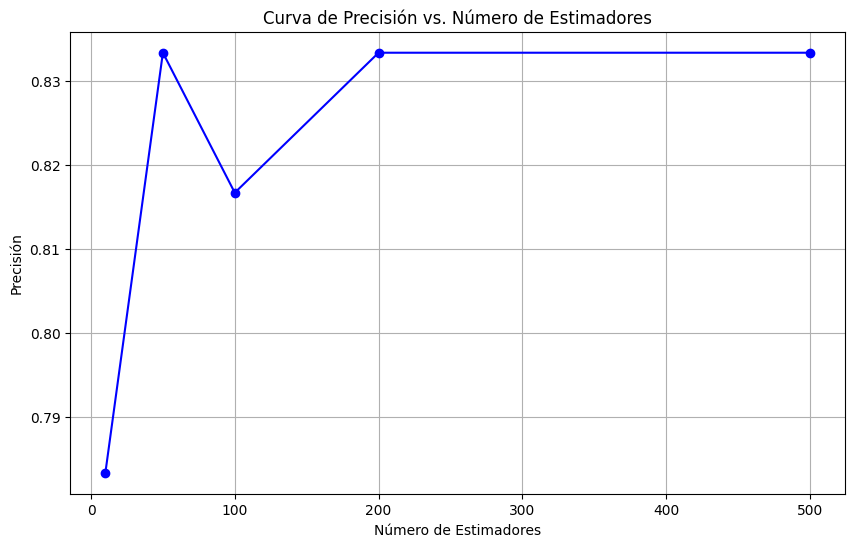

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(scores_df["n_estimators"], scores_df["accuracy"], marker="o", linestyle="-", color="b")
plt.xlabel("Número de Estimadores")
plt.ylabel("Precisión")
plt.title("Curva de Precisión vs. Número de Estimadores")
plt.grid(True)
plt.show()

Observamos que a partir de los 50 estimadores la precision se manteine alrededor de los 0.8333, con una pequeña baja a los 100, pero amesetandose.

In [ ]:
# Pregunta 2
rf_model_features_none = RandomForestClassifier(n_estimators=100, random_state=100, oob_score=True, max_features=None)

# Entrenar el modelo con los datos de entrenamiento
rf_model_features_none.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_features_none = rf_model_features_none.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con max_features=None ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_features_none):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_features_none.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_features_none.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_features_none))

--- Evaluación de Random Forest con 10 estimadores ---
Accuracy: 0.8333
Error OOB (Out-of-Bag): 0.2532
Accuracy OOB: 0.7468

Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.91      0.85        32
         Yes       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



/Users/rodrigoecheconea/Projects/Master AI/aprendizaje_automatico/.venv/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [23]:
rf_model_features_2 = RandomForestClassifier(n_estimators=100, random_state=100, oob_score=True, max_features=2)

# Entrenar el modelo con los datos de entrenamiento
rf_model_features_2.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_features_2 = rf_model_features_2.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con max_features=2 ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_features_2):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_features_2.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_features_2.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_features_2))

--- Evaluación de Random Forest con max_features=2 ---
Accuracy: 0.8500
Error OOB (Out-of-Bag): 0.2068
Accuracy OOB: 0.7932

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.88      0.86        32
         Yes       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [21]:
rf_model_features_sqrt = RandomForestClassifier(n_estimators=100, random_state=100, oob_score=True, max_features='sqrt')

# Entrenar el modelo con los datos de entrenamiento
rf_model_features_sqrt.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf_features_sqrt = rf_model_features_sqrt.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Random Forest con max_features=sqrt(p) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_features_sqrt):.4f}")
print(f"Error OOB (Out-of-Bag): {1 - rf_model_features_sqrt.oob_score_:.4f}") # Error OOB
print(f"Accuracy OOB: {rf_model_features_sqrt.oob_score_:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_features_sqrt))

--- Evaluación de Random Forest con max_features=sqrt(p) ---
Accuracy: 0.8167
Error OOB (Out-of-Bag): 0.2025
Accuracy OOB: 0.7975

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.88      0.84        32
         Yes       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



In [22]:
resultado_features = pd.DataFrame({
    "max_features": ["None", "2", "sqrt(p)"],
    "accuracy": [accuracy_score(y_test, y_pred_rf_features_none), accuracy_score(y_test, y_pred_rf_features_2), accuracy_score(y_test, y_pred_rf_features_sqrt)],
    "error_oob": [1 - rf_model_features_none.oob_score_, 1 - rf_model_features_2.oob_score_, 1 - rf_model_features_sqrt.oob_score_]
})
resultado_features


,max_features,accuracy,error_oob
0,None,0.833333,0.253165
1,2,0.850000,0.206751
2,sqrt(p),0.816667,0.202532


Los resultados nos muestran que con maximo 2 features obtenemos la mejor precision y con sqrt el menor error oob. Em ambos casos, None no fue el mejor resultado, posiblemente porque al considerar todas las variables los árboles se parecen más entre sí y se pierde parte de la diversidad del Random Forest.

## 4. Gradient Boosting

Ahora, probaremos con Gradient Boosting. A diferencia de Random Forest, este método construye los árboles de forma secuencial, donde cada nuevo árbol intenta corregir los errores de los anteriores. Es conocido por su alto rendimiento, aunque puede ser más sensible a los hiperparámetros.

In [24]:
# Instanciar el clasificador de Gradient Boosting
# n_estimators: número de árboles secuenciales.
# learning_rate: factor de contracción (shrinkage) para cada árbol.
# max_depth: profundidad máxima de cada árbol (suelen ser superficiales).
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
gb_model.fit(X_train, y_train)

# Realizar predicciones
y_pred_gb = gb_model.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

--- Evaluación de Gradient Boosting ---
Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.84      0.86        32
         Yes       0.83      0.86      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



### 4.1. Comparación de Matrices de Confusión

La precisión general es útil, pero una matriz de confusión nos da más detalles sobre el tipo de errores que comete cada modelo (Falsos Positivos vs. Falsos Negativos), lo cual es crucial en problemas médicos.

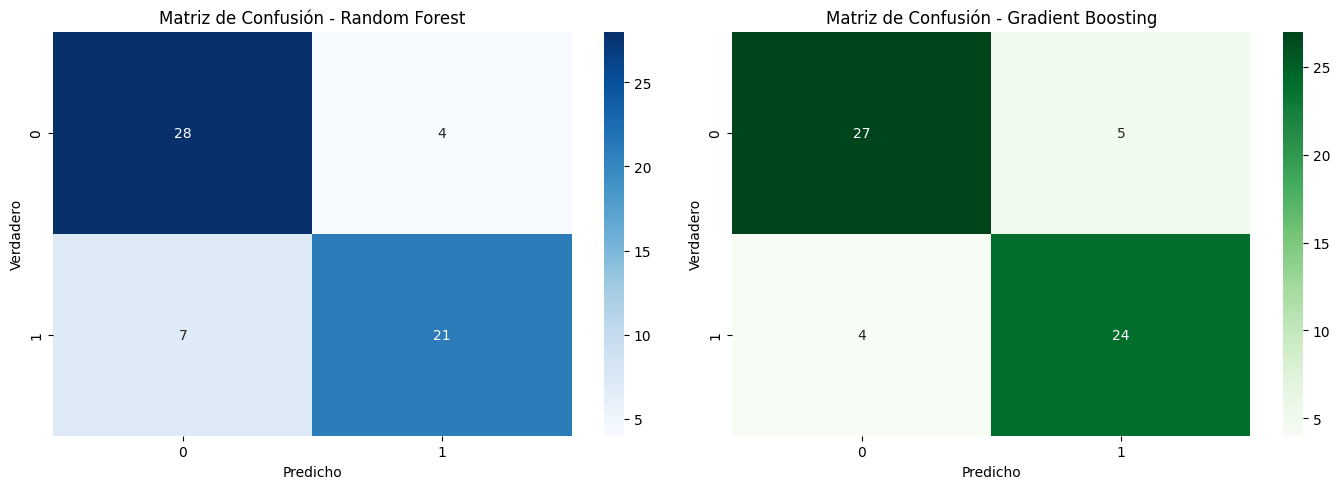

In [25]:
# Calcular matrices de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - Random Forest')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Verdadero')

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión - Gradient Boosting')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Verdadero')

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
import plotly.express as px
from sklearn.metrics import roc_curve, auc

# Calcular ROC y AUC para ambos modelos
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test.map({"No": 0, "Yes": 1}), rf_model.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test.map({"No": 0, "Yes": 1}), gb_model.predict_proba(X_test)[:, 1])
roc_auc_gb = auc(fpr_gb, tpr_gb)

roc_df = pd.DataFrame({
    "FPR": list(fpr_rf) + list(fpr_gb), "TPR": list(tpr_rf) + list(tpr_gb),
    "Threshold": list(thresholds_rf) + list(thresholds_gb),
    "Model": (["Random Forest"] * len(fpr_rf)) + (["Gradient Boosting"] * len(fpr_gb))
})
fig = px.line(
    roc_df, x="FPR", y="TPR", color="Model", line_dash="Model", title="ROC Curves",
    labels={"FPR": "False Positive Rate (FPR)", "TPR": "True Positive Rate (TPR)"}, hover_data=["Threshold"]
)
fig.add_shape(
    type="line", x0=0, y0=0, x1=1, y1=1,
    line=dict(color="red", dash="dash")
)
fig.for_each_trace(
    lambda t: t.update(
        name=f"{t.name} (AUC = {roc_auc_rf:.2f})" if "Random Forest" in t.name else f"{t.name} (AUC = {roc_auc_gb:.2f})"
    )
)
fig.update_layout(
    width=800, height=500,legend=dict(
        x=0.98, y=0.02, xanchor="right", yanchor="bottom",
        bgcolor="rgba(255,255,255,0.7)", bordercolor="black", borderwidth=1)
)
fig.show()

### ❔ Preguntas para Reflexionar (Gradient Boosting)

1.  **El trade-off `learning_rate` y `n_estimators`**: Reduce el `learning_rate` a `0.01`. ¿Cómo afecta esto a la precisión? ¿Necesitás más `n_estimators` para compensar? ¿Qué pasa si aumentás el `learning_rate` a `0.5`?
2.  **Importancia de `max_depth`**: En Boosting, los árboles suelen ser superficiales. Probá con `max_depth=1` (stumps). ¿Cómo se compara el resultado con `max_depth=3`?
3.  **Análisis de errores**: Basándote en las matrices de confusión, ¿qué modelo es mejor para minimizar los **falsos negativos** (predecir 'No' cuando en realidad es 'Sí')? ¿Por qué esto podría ser lo más importante en un contexto de diagnóstico médico?

In [27]:
# Pregunta 1
gb_model_001 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, random_state=42)

# Entrenar el modelo
gb_model_001.fit(X_train, y_train)

# Realizar predicciones
y_pred_gb_001 = gb_model_001.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb_001):.4f}")

--- Evaluación de Gradient Boosting ---
Accuracy: 0.8333


Partimos de un accuracy de 0.8500 y nos fuimos a uno de 0.8333. Vamos a probar mas estimadores.

In [28]:
gb_model_001_estimators_200 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=3, random_state=42)

# Entrenar el modelo
gb_model_001_estimators_200.fit(X_train, y_train)

# Realizar predicciones
y_pred_gb_001_estimators_200 = gb_model_001_estimators_200.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb_001_estimators_200):.4f}")

--- Evaluación de Gradient Boosting ---
Accuracy: 0.8167


Empeora, sumar mas estimadores no ayuda con un learning_rate tan bajo.

In [29]:
# Aumento el learning_rate a 0.5
gb_model_05 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.5, max_depth=3, random_state=42)

# Entrenar el modelo
gb_model_05.fit(X_train, y_train)

y_pred_gb_05 = gb_model_05.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb_05):.4f}")


--- Evaluación de Gradient Boosting ---
Accuracy: 0.8333


Tampoco mejora, 0.1 debe ser el valor mas acertado.

In [30]:
# Pregunta 2
gb_model_max_depth_1 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=1, random_state=42)

# Entrenar el modelo
gb_model_max_depth_1.fit(X_train, y_train)

y_pred_gb_max_depth_1 = gb_model_max_depth_1.predict(X_test)

# Evaluar el rendimiento
print("--- Evaluación de Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb_max_depth_1):.4f}")



--- Evaluación de Gradient Boosting ---
Accuracy: 0.8333


El resultado tampoco mejora.

#### Pregunta 3
El gradient boosting dio un numero menor de falsos negativos que el random forest. En el contexto medico es de suma importancia porque implica decirle a alguien que no tiene una enfermedad dada cuando en verdad la tiene.

## 5. Ejercicios Adicionales

A continuación, se proponen ejercicios para profundizar los conceptos vistos y experimentar por tu cuenta.

1.  **Optimización de Profundidad:** Para ambos modelos (RF y GB), variá el hiperparámetro `max_depth` (ej. 2, 3, 5, 10) y analizá cómo afecta a la precisión en el conjunto de prueba. ¿Observás sobreajuste en alguno de los modelos cuando la profundidad es muy alta?

2.  **Visualizar el Error OOB:** En el modelo de Random Forest, el atributo `oob_score_` se calcula sobre el ensamble final. Para visualizar la curva, entrená varios modelos con diferente `n_estimators` (de 10 a 200, por ejemplo) y graficá el error OOB (`1 - oob_score_`) en función del número de árboles.

3.  **Curva de Aprendizaje en Boosting:** Para el modelo de Gradient Boosting, podés acceder al error en cada etapa de la construcción secuencial. Utilizá el método `staged_predict()` para obtener las predicciones en cada iteración y graficá el error de prueba en función del número de árboles. ¿Observás un punto donde el error deja de bajar y empieza a subir (sobreajuste)?

4.  **Importancia de Variables en Boosting:** Al igual que con Random Forest, los modelos de Gradient Boosting también tienen el atributo `.feature_importances_`. Extraé y visualizá la importancia de las variables para el modelo `gb_model`. ¿Coinciden las variables más importantes con las de Random Forest?

5.  **Análisis de Probabilidades:** En lugar de predecir la clase directamente (`.predict()`), utiliza `.predict_proba()` para obtener las probabilidades. ¿Cómo podrías ajustar el umbral de decisión (por defecto es 0.5) para, por ejemplo, ser más sensible y capturar más casos positivos, aunque aumenten los falsos positivos?

6.  **Investigar XGBoost:** Lee la documentación de la popular librería `xgboost`. Instalala (`!pip install xgboost`) e impleméntala en este mismo problema. Compará su rendimiento y velocidad con el `GradientBoostingClassifier` de Scikit-learn.

7. **Conclusión Final:** Escribí un párrafo en una celda de Markdown resumiendo tus hallazgos. ¿Qué modelo funcionó mejor para este problema? ¿Cuál recomendarías para un despliegue en producción y por qué, considerando la precisión, la interpretabilidad y el costo computacional?